<a href="https://colab.research.google.com/github/nguyentran31241022940-byte/may_hoc_cuoi_ky/blob/main/mayhoccuoiki_hoiquy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH BỘI
Biến                           Hệ số    p-value    Ý nghĩa
-------------------------------------------------------
Hệ số tự do                  -2.2681     0.0301          *
total_minutes                 0.1033     0.0000        ***
total_calls                   0.0018     0.5176      không
number_vmail_messages         0.0241     0.3125      không
number_customer_service_calls    -0.0361     0.6395      không
intl_plan                     0.5813     0.0599      không
voice_mail_plan              -0.6761     0.3512      không

Đánh giá trên tập huấn luyện:
  R²   = 0.7939
  MAE  = 3.7624
  RMSE = 4.6816

Đánh giá trên tập kiểm tra:
  R²   = 0.7999
  MAE  = 3.7811
  RMSE = 4.7147


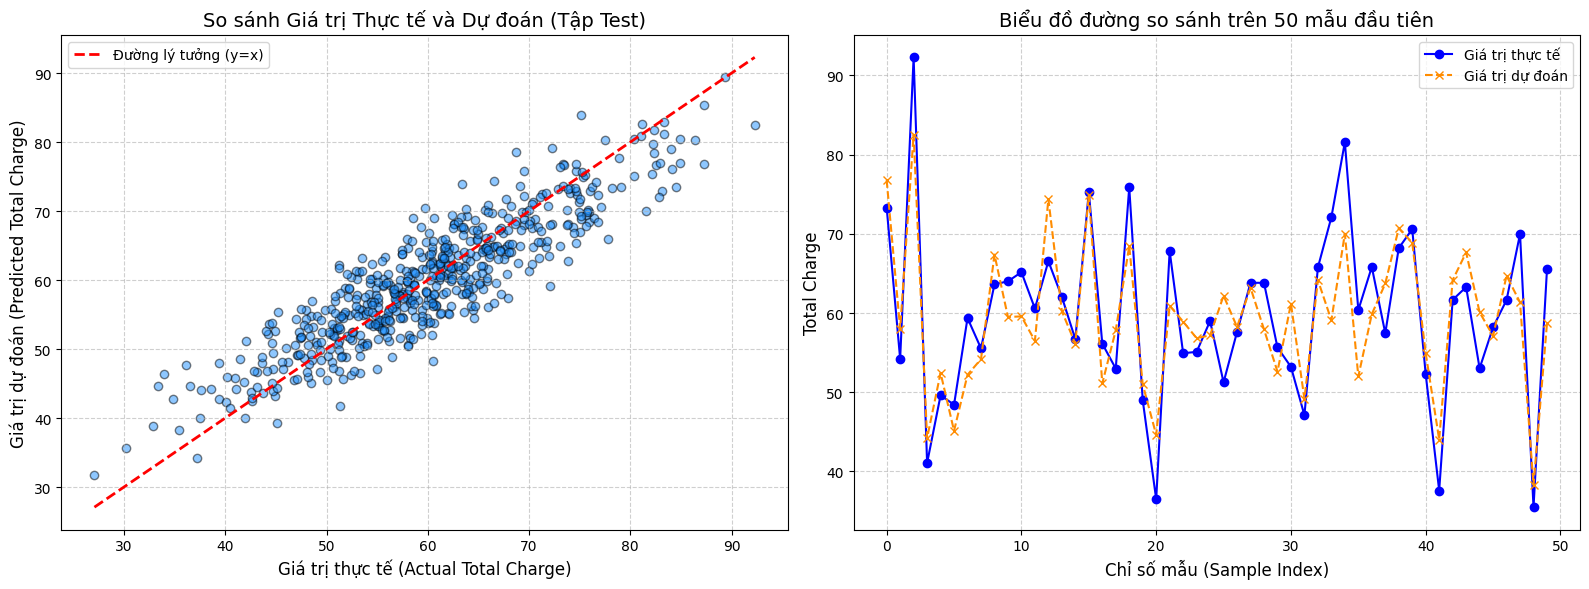

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files


uploaded = files.upload()  # Chọn cả 2 file CSV

df      = pd.read_csv('churn-bigml-80.csv')
df_test = pd.read_csv('churn-bigml-20.csv')


for dataset in [df, df_test]:
    dataset.columns = dataset.columns.str.strip().str.lower().str.replace(' ', '_')
    dataset.rename(columns={
        'churn'                 : 'churned',
        'international_plan'   : 'intl_plan',
        'customer_service_calls': 'number_customer_service_calls'
    }, inplace=True)

# Đặt lại index cho tập train
r_index = ['r{}'.format(i) for i in range(len(df))]
df.index = r_index
df.index.name = 'INDEX'


df.isna().any()

df = df.dropna()
df_test = df_test.dropna()

df.drop(['state','account_length','area_code',], axis = 1, inplace = True)
df_test.drop(['state','account_length','area_code'], axis = 1, inplace = True)

# Chuyển toàn bộ giá trị trong hai cột về chữ thường
df['intl_plan'] = df['intl_plan'].str.lower()
df['voice_mail_plan'] = df['voice_mail_plan'].str.lower()

df_test['intl_plan'] = df_test['intl_plan'].str.lower()
df_test['voice_mail_plan'] = df_test['voice_mail_plan'].str.lower()

from sklearn.preprocessing import LabelEncoder

object_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
object_cols.remove('churned')

for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    df_test[col] = le.transform(df_test[col])  # chỉ transform, không fit lại

# Cuối cùng encode cột target (chỉ nên fit trên train)
target_le = LabelEncoder()
df['churned'] = target_le.fit_transform(df['churned'])
df_test['churned'] = target_le.transform(df_test['churned'])

from scipy import stats
import numpy as np

# Lọc các cột số, trừ 'churned' (nếu có)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('churned', errors='ignore')

# Tính Z-score cho toàn bộ cột số
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Giữ các hàng có Z-score < 3 ở **tất cả các cột**
df = df[(z_scores < 3).all(axis=1)]

#--------- Tập test ------------------
numeric_cols = df_test.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('churned', errors='ignore')

# Tính Z-score cho toàn bộ cột số
z_scores = np.abs(stats.zscore(df_test[numeric_cols], nan_policy='omit'))

# Giữ các hàng có Z-score < 3 ở **tất cả các cột**
df_test = df_test[(z_scores < 3).all(axis=1)]



X_train= df.drop('churned',axis =1)
y_train = df['churned']


X_test = df_test.drop('churned',axis =1)
y_test = df_test['churned']

# ================================================================
# BƯỚC 1: TẠO BIẾN TỔNG HỢP
# ================================================================
for dataset in [df, df_test]:
    dataset['total_minutes'] = (dataset['total_day_minutes'] + dataset['total_eve_minutes'] +
                                dataset['total_night_minutes'] + dataset['total_intl_minutes'])
    dataset['total_calls']   = (dataset['total_day_calls'] + dataset['total_eve_calls'] +
                                dataset['total_night_calls'] + dataset['total_intl_calls'])
    dataset['total_charge']  = (dataset['total_day_charge'] + dataset['total_eve_charge'] +
                                dataset['total_night_charge'] + dataset['total_intl_charge'])

# ================================================================
# BƯỚC 2: ĐỊNH NGHĨA BIẾN ĐỘC LẬP VÀ BIẾN PHỤ THUỘC
# ================================================================
features = ['total_minutes', 'total_calls','number_vmail_messages','number_customer_service_calls','intl_plan','voice_mail_plan']
X_train_reg = df[features]
y_train_reg = df['total_charge']

X_test_reg  = df_test[features]
y_test_reg  = df_test['total_charge']

# ================================================================
# BƯỚC 3: XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH
# ================================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats
import numpy as np

model_reg = LinearRegression()
model_reg.fit(X_train_reg, y_train_reg)

y_pred_train = model_reg.predict(X_train_reg)
y_pred_test  = model_reg.predict(X_test_reg)

# ================================================================
# BƯỚC 4: KIỂM ĐỊNH Ý NGHĨA THỐNG KÊ TỪNG BIẾN (p-value)
# ================================================================
n = len(X_train_reg)
p = X_train_reg.shape[1]
X_const = np.column_stack([np.ones(n), X_train_reg])
residuals_train = y_train_reg - y_pred_train
sigma2 = np.sum(residuals_train**2) / (n - p - 1)
cov_matrix = sigma2 * np.linalg.inv(X_const.T @ X_const)
std_errors = np.sqrt(np.diag(cov_matrix))
coefs_full = np.concatenate([[model_reg.intercept_], model_reg.coef_])
t_stats  = coefs_full / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))

print("=" * 55)
print("KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH BỘI")
print("=" * 55)
print(f"{'Biến':<25} {'Hệ số':>10} {'p-value':>10} {'Ý nghĩa':>10}")
print("-" * 55)
names = ['Hệ số tự do'] + features
for name, coef, pv in zip(names, coefs_full, p_values):
    sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'không'))
    print(f"{name:<25} {coef:>10.4f} {pv:>10.4f} {sig:>10}")

# ================================================================
# BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH
# ================================================================
print(f"\nĐánh giá trên tập huấn luyện:")
print(f"  R²   = {r2_score(y_train_reg, y_pred_train):.4f}")
print(f"  MAE  = {mean_absolute_error(y_train_reg, y_pred_train):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_train_reg, y_pred_train)):.4f}")

print(f"\nĐánh giá trên tập kiểm tra:")
print(f"  R²   = {r2_score(y_test_reg, y_pred_test):.4f}")
print(f"  MAE  = {mean_absolute_error(y_test_reg, y_pred_test):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test_reg, y_pred_test)):.4f}")

# Cài đặt kích thước biểu đồ
plt.figure(figsize=(16, 6))


# ----------------------------------------------------------------
# Đồ thị 1: Biểu đồ phân tán (Scatter plot) - Thực tế vs Dự đoán
# ----------------------------------------------------------------
plt.subplot(1, 2, 1)
plt.scatter(y_test_reg, y_pred_test, alpha=0.5, color='dodgerblue', edgecolor='k')

# Vẽ đường y = x (Đường lý tưởng, dự đoán chính xác 100%)
min_val = min(y_test_reg.min(), y_pred_test.min())
max_val = max(y_test_reg.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng (y=x)')

plt.title('So sánh Giá trị Thực tế và Dự đoán (Tập Test)', fontsize=14)
plt.xlabel('Giá trị thực tế (Actual Total Charge)', fontsize=12)
plt.ylabel('Giá trị dự đoán (Predicted Total Charge)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# ----------------------------------------------------------------
# Đồ thị 2: Biểu đồ đường (Line plot) - 50 mẫu đầu tiên
# ----------------------------------------------------------------
plt.subplot(1, 2, 2)

# Chọn 50 điểm dữ liệu đầu tiên để dễ quan sát
subset_actual = y_test_reg.values[:50]
subset_pred = y_pred_test[:50]

plt.plot(subset_actual, label='Giá trị thực tế', marker='o', linestyle='-', color='blue')
plt.plot(subset_pred, label='Giá trị dự đoán', marker='x', linestyle='--', color='darkorange')

plt.title('Biểu đồ đường so sánh trên 50 mẫu đầu tiên', fontsize=14)
plt.xlabel('Chỉ số mẫu (Sample Index)', fontsize=12)
plt.ylabel('Total Charge', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()